https://chatgpt.com/c/6738608a-412c-800d-a496-b35742e2862e

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import cv2
import os, glob
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D,GlobalAveragePooling2D,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, LSTM
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [2]:
data_train = r"dataset\Train"
data_test = r"dataset\Test"
fake=[]
for file in os.listdir(data_test):
    if file[0] =='.':
        continue
    fake+=[file]
print(fake)
print(len(fake))

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
9


In [3]:
img_height,img_width=256,256
batch_size=20

train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(data_train,
                                                target_size=(img_height,img_width),
                                                batch_size=batch_size,
                                                class_mode='categorical',
                                               )
test_generator = train_datagen.flow_from_directory(data_test,
                                                target_size=(img_height,img_width),
                                                batch_size=batch_size,
                                                class_mode='categorical',
                               
                                               )

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


In [4]:
precision=tf.keras.metrics.Precision()
recall=tf.keras.metrics.Recall()
sensitivity=tf.keras.metrics.SensitivityAtSpecificity(0.1)
specificity=tf.keras.metrics.SpecificityAtSensitivity(0.1)

In [5]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

# ResNet

In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [7]:
# Load the ResNet50 model with pre-trained weights, excluding the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model to retain pre-trained weights
base_model.trainable = False

# Build the model
model_resnet = Sequential([
    base_model,  # Add the pre-trained ResNet50 base model
    GlobalAveragePooling2D(),  # Pooling to reduce the feature map
    Dense(1024, activation='relu'),  # Fully connected layer
    Dropout(0.5),  # Dropout for regularization
    Dense(512, activation='relu'),  # Fully connected layer
    Dropout(0.5),  # Dropout for regularization
    Dense(256, activation='relu'),  # Fully connected layer
    BatchNormalization(),  # Batch normalization to stabilize training
    Dense(128, activation='relu'),  # Fully connected layer
    Dropout(0.3),  # Dropout for regularization
    Dense(9, activation='softmax')  # Output layer for 9 classes
])

# Compile the model
model_resnet.compile(optimizer=Adam(learning_rate=0.0001),
                     loss="categorical_crossentropy",
                     metrics=['accuracy'])

# Display model summary
model_resnet.summary()


94765736/94765736 [==============================] - 10s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1024)              2098176   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               

In [8]:
# Train the model
hist_resnet = model_resnet.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator
)

Epoch 1/50


112/112 [==============================] - 293s 3s/step - loss: 2.7726 - accuracy: 0.1072 - val_loss: 2.1765 - val_accuracy: 0.1356
Epoch 2/50
112/112 [==============================] - 236s 2s/step - loss: 2.6043 - accuracy: 0.1277 - val_loss: 2.2141 - val_accuracy: 0.1356
Epoch 3/50
112/112 [==============================] - 229s 2s/step - loss: 2.5079 - accuracy: 0.1617 - val_loss: 2.2031 - val_accuracy: 0.1356
Epoch 4/50
112/112 [==============================] - 257s 2s/step - loss: 2.4499 - accuracy: 0.1510 - val_loss: 2.1905 - val_accuracy: 0.1356
Epoch 5/50
112/112 [==============================] - 259s 2s/step - loss: 2.3906 - accuracy: 0.1581 - val_loss: 2.1403 - val_accuracy: 0.1356
Epoch 6/50
112/112 [==============================] - 232s 2s/step - loss: 2.3759 - accuracy: 0.1648 - val_loss: 2.1375 - val_accuracy: 0.1356
Epoch 7/50
112/112 [==============================] - 248s 2s/step - loss: 2.3403 - accuracy: 0.1746 - val_loss: 2.1569 - val_accuracy: 0.13

In [9]:
# Save the model
model_resnet.save("models/ResNet50.h5")

C:\Users\0877\AppData\Roaming\Python\Python310\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


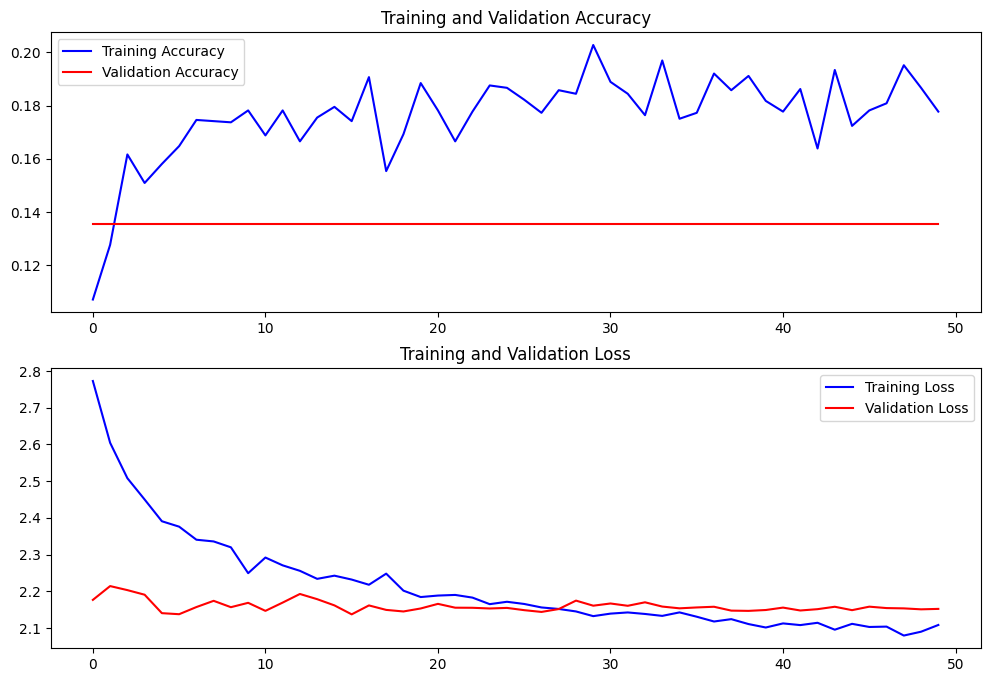

In [10]:
# Plot training history
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(hist_resnet.history['accuracy'], label='Training Accuracy', color='b')
ax[0].plot(hist_resnet.history['val_accuracy'], label='Validation Accuracy', color='r')
ax[0].legend(loc='best')
ax[0].set_title("Training and Validation Accuracy")

ax[1].plot(hist_resnet.history['loss'], label='Training Loss', color='b')
ax[1].plot(hist_resnet.history['val_loss'], label='Validation Loss', color='r')
ax[1].legend(loc='best')
ax[1].set_title("Training and Validation Loss")
plt.show()

In [11]:
# Evaluate the model
filenames = test_generator.filenames
nb_samples = len(filenames)
model_predictions = model_resnet.predict(test_generator, steps=nb_samples, verbose=2)
y_true = test_generator.classes
y_pred = model_predictions.argmax(axis=1)

118/118 - 15s - 15s/epoch - 125ms/step


Confusion matrix, without normalization
[[ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0  3  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0  3  0  0  0]]


<Axes: title={'center': 'Confusion Matrix (ResNet50)'}, xlabel='Predicted label', ylabel='True label'>

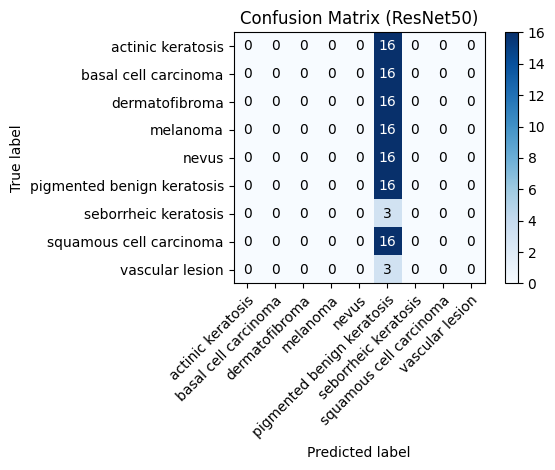

: 

In [12]:
# Confusion matrix
plot_confusion_matrix(y_true, y_pred, classes=[
    'actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 
    'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 
    'squamous cell carcinoma', 'vascular lesion'],
    title='Confusion Matrix (ResNet50)'
)